In [1]:
from econml.orf import DMLOrthoForest, DROrthoForest
from econml.dml import CausalForestDML
from econml.sklearn_extensions.linear_model import WeightedLassoCVWrapper, WeightedLasso
from sklearn.model_selection import train_test_split

# Helper imports
import numpy as np
from itertools import product
from sklearn.linear_model import Lasso, LogisticRegression
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from scipy.special import expit 
import os
import pandas as pd
import urllib.request
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict

from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor
)

okabe_ito = {
    "orange":    "#E69F00",
    "sky_blue":  "#56B4E9",
    "green":     "#009E73",
    "yellow":    "#F0E442",
    "blue":      "#0072B2",
    "vermilion": "#D55E00",
    "pink":      "#CC79A7",
    "black":     "#000000",
}

oi_colors = list(okabe_ito.values())

%matplotlib inline

In [ ]:
# How do we simulate data?



In [2]:
# We are going to load the data from the EconML site:

oj_data = pd.read_csv("https://raw.githubusercontent.com/py-why/EconML/refs/heads/data/datasets/OrangeJuice/oj_large.csv")

oj_data.head()

,store,brand,week,logmove,feat,price,AGE60,EDUC,ETHNIC,INCOME,HHLARGE,WORKWOM,HVAL150,SSTRDIST,SSTRVOL,CPDIST5,CPWVOL5
0,2,tropicana,40,9.018695,0,3.87,0.232865,0.248935,0.11428,10.553205,0.103953,0.303585,0.463887,2.110122,1.142857,1.92728,0.376927
1,2,tropicana,46,8.723231,0,3.87,0.232865,0.248935,0.11428,10.553205,0.103953,0.303585,0.463887,2.110122,1.142857,1.92728,0.376927
2,2,tropicana,47,8.253228,0,3.87,0.232865,0.248935,0.11428,10.553205,0.103953,0.303585,0.463887,2.110122,1.142857,1.92728,0.376927
3,2,tropicana,48,8.987197,0,3.87,0.232865,0.248935,0.11428,10.553205,0.103953,0.303585,0.463887,2.110122,1.142857,1.92728,0.376927
4,2,tropicana,50,9.093357,0,3.87,0.232865,0.248935,0.11428,10.553205,0.103953,0.303585,0.463887,2.110122,1.142857,1.92728,0.376927


In [3]:

# Prepare the data
Y = oj_data['logmove'].values  # The target is the log of the moving average of OJ sales
T = oj_data['feat'].values  # Featured is the treatment variable
scaler = StandardScaler()  # We will use the standard scaler

# We scale the continuous features (exclude feat since it's now the treatment)

W1 = scaler.fit_transform(oj_data[[c for c in oj_data.columns
                                   if c not in ['logmove', 'brand', 'week', 'store', 'feat']]].values)

# We one-hot the brand variables
W2 = pd.get_dummies(oj_data[['brand']]).values
W = np.concatenate([W1, W2], axis=1)

# This is the variable we are interested in exploring as a modifier

X = oj_data[['INCOME']].values

In [4]:
oj_data['logmove'].mean()

np.float64(9.167863993162849)

In [5]:
# Before we do any fitting to the real data, we are going to see if our model could successfully find causal effects
# in fake data

# The idea is that we are going to use the real values of the confounders (The W) and the effect modifier (the X)
# While simulating the outcome variable


n, n_w = W.shape  
income_min, income_max = X.min(), X.max()

def true_cate(X):
    # Doesn't really matter what we put here, just something nonlinear that is generally
    # going to show a positive effect
    x_sc = (X - income_min) / (income_max - income_min)
    return 0.1 + 0.3 * np.sin(np.pi * x_sc)

TE_true = true_cate(X).ravel() # We calculate the true treatment effect



rng = np.random.default_rng(11111)

# Now we are going to pick 5 features from the confounder
# matrix W to be "real" confounders. These features each will
# have a random impact on both the treatment and outcome
# The hardest case is when the confounders impact both treatment and outcome
# so that is what we simulate

support_size = 5 # The number of features
support_idx = rng.choice(n_w, size=support_size, replace=False) # Select the indices

# First we will model the probability of receiving the treatment



gamma = rng.uniform(-0.5, 0.5, size=support_size) # These are the effects of each confounder on propensity. We make sure they are nontrivial
propensity_logit = W[:, support_idx] @ gamma
propensity = expit(propensity_logit - propensity_logit.mean() - 1.0)  # This will make it so about 25% is treated, which is close to the true rate


# Now we create the treatment variable
# Here propoensity is the vector of treatment propensities, and we do 1 trial per element of this vector
T_sim = np.random.binomial(1, propensity)


# These are the effects of the confounders on logsales. We don't want it to big,
# remember that most things in social science/econ have small effects. These
# are probably pushing it
beta = rng.uniform(-0.3, 0.3, size=support_size)

# So we extract the confounders that matter and matrix multiply them by the effects. 
# For each observation this gives us the impact of the confounders on the logsales

mu_W = W[:, support_idx] @ beta


# Now we simulate the outcome

epsilon = np.random.normal(0, 0.5, size=n)

# We add the confounder effect, the treatment effect, the noise, and the mean
Y_sim = mu_W + TE_true * T_sim + epsilon + 9.1


In [6]:
# Now we set up the Causal Forest Double Machine Learning model

# We will use Lasso to model the impact on the log sales of the confounders, and logistic regression
# to model impact on the treatment. We could use L1 penalization with logistic regression too if
# we wanted.

# The other hyperparameters we are keeping from the EconML vignette, except discrete treatment

est = CausalForestDML(
    model_y=LassoCV(cv=3),
    model_t=LogisticRegressionCV(cv=3),
    n_estimators=8000,
    min_samples_leaf=10,
    max_depth=40,
    max_samples=0.45,
    discrete_treatment=True,
    random_state=123
)

# Fit the model, X and W are our real data, Y_sim and T_sim our simulated treatment and outcome
est.fit(Y_sim, T_sim, X=X, W=W)

/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LogisticRegressionCV(cv=3) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")
/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LassoCV(cv=3) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")


In [7]:
# Now we are going to calculate and visualize the effect that we modeled

# This is the grid of incomes we want to see the effects for
X_test = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# We calculate the sales effect predicted by the model for each income
cate = est.effect(X_test)

# We will do this for visualization
cate_lower, cate_upper = est.effect_interval(X_test)

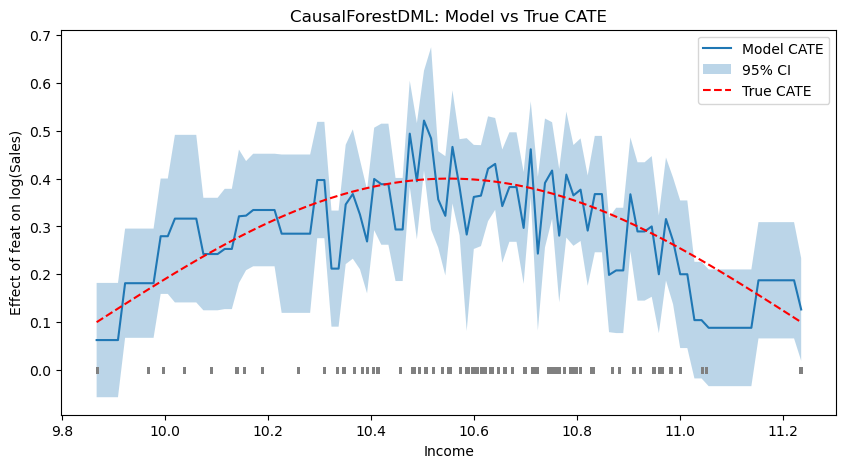

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(X_test.flatten(), cate, label="Model CATE")
plt.fill_between(X_test.flatten(), cate_lower, cate_upper, label="95% CI", alpha=0.3)
plt.plot(X_test.flatten(), true_cate(X_test).ravel(), 'r--', label="True CATE")
plt.plot(X.ravel(), np.zeros_like(X.ravel()), '|', color='gray', alpha=0.1, markersize=5)
plt.xlabel('Income')
plt.ylabel('Effect of feat on log(Sales)')
plt.legend()
plt.title("CausalForestDML: Model vs True CATE")
plt.show()

In [11]:
ate_hat = est.ate(X=X)
ate_ci = est.ate_interval(X=X, alpha=0.05)
ate_true = TE_true.mean()

AttributeError: 'CausalForestDML' object has no attribute '_d_t_in'

In [12]:
ate_true
ate_hat
ate_ci

NameError: name 'ate_true' is not defined

In [13]:
# Now we do a train test split of our data:



idx_train, idx_test = train_test_split(
    np.arange(len(Y)), test_size=0.2, random_state=319
)

Y_train, Y_test = Y[idx_train], Y[idx_test]
T_train, T_test = T[idx_train], T[idx_test]
W_train, W_test = W[idx_train], W[idx_test]
X_train, X_test = X[idx_train], X[idx_test]

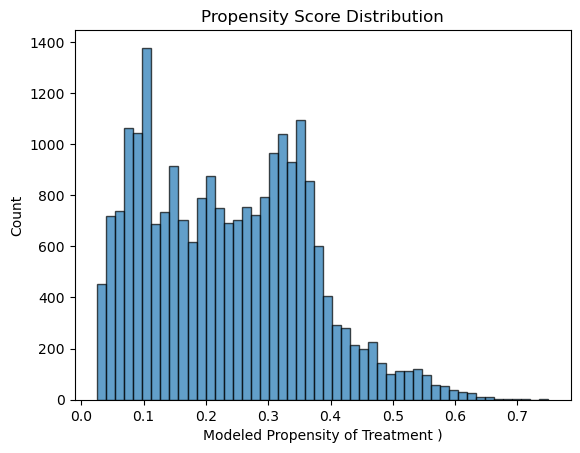

In [14]:
propensity_hat = cross_val_predict(
    LogisticRegressionCV(cv=3), W_train, T_train, cv=3, method='predict_proba'
)[:, 1]


plt.hist(propensity_hat, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Modeled Propensity of Treatment )')
plt.ylabel('Count')
plt.title('Propensity Score Distribution')
plt.show()

In [15]:
# Now let's fit the model


est = CausalForestDML(
    model_y=LassoCV(cv=3),
    model_t=LogisticRegressionCV(cv=3),
    n_estimators=8000,
    min_samples_leaf=10,
    max_depth=40,
    max_samples=0.45,
    discrete_treatment=True,
    random_state=123
)

# Fit the model, X and W are our real data, Y_sim and T_sim our simulated treatment and outcome
est.fit(Y_train, T_train, X=X_train, W=W_train)


/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LogisticRegressionCV(cv=3) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")
/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LassoCV(cv=3) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")


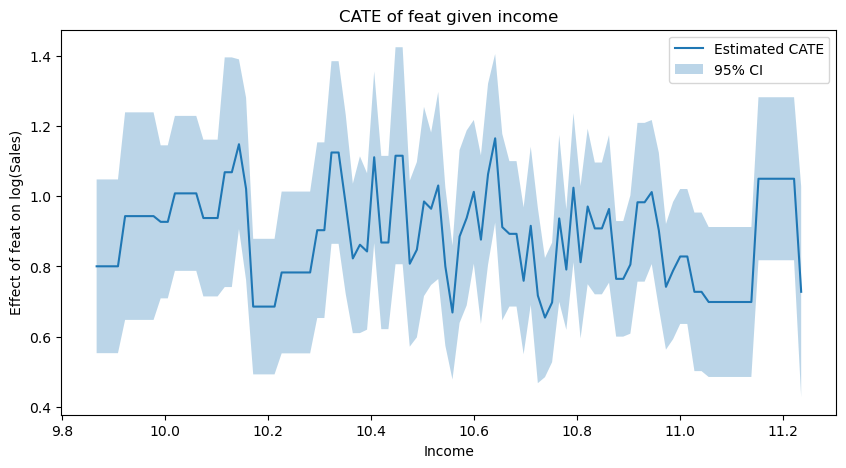

In [16]:
# Now we do the same visualization as before:


X_grid = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
cate = est.effect(X_grid)
cate_lower, cate_upper = est.effect_interval(X_grid, alpha=0.05)

plt.figure(figsize=(10, 5))
plt.plot(X_grid.flatten(), cate, label="Estimated CATE")
plt.fill_between(X_grid.flatten(), cate_lower, cate_upper,
                 label="95% CI", alpha=0.3)
plt.xlabel('Income')
plt.ylabel('Effect of feat on log(Sales)')
plt.legend()
plt.title("CATE of feat given income")
plt.show()



In [47]:
ate = est.ate(X=X_train)
ate_lb, ate_ub = est.ate_interval(X=X_train, alpha=0.05)
ate

np.float64(1.274213539902918)

In [49]:
rscore = est.score(Y_test, T_test, X=X_test, W=W_test)
rscore


0.6827115726947284

In [51]:
sens_lb, sens_ub = est.sensitivity_interval(alpha=0.05, c_t=0.1, c_y=0.3)